In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('train_backpack.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


Text(0.5, 1.0, 'Пропущенные значения')

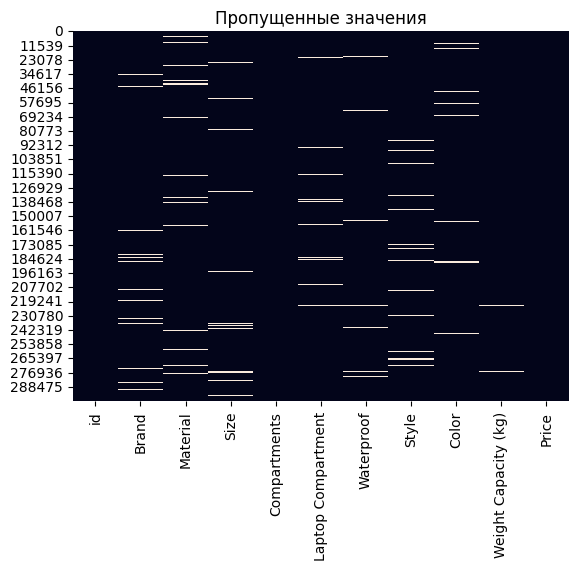

In [ ]:
sns.heatmap(df.isnull(), cbar = False).set_title("Пропущенные значения")

In [ ]:
print("Число пропущенных значений до обработки:")
print(df.isnull().sum())

Число пропущенных значений до обработки:
id                         0
Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64


In [ ]:
categorical_cols = ['Brand','Material','Size','Laptop Compartment','Waterproof','Style','Color']
for col in categorical_cols:
    if df[col].isnull().any():
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Заполнены пропуски в категориальном столбце '{col}' модой: {mode_value}")

numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df[col].isnull().any():
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Заполнены пропуски в числовом столбце '{col}' медианой: {median_value}")


Заполнены пропуски в категориальном столбце 'Brand' модой: Adidas


<ipython-input-58-8d4960591c65>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


Заполнены пропуски в категориальном столбце 'Material' модой: Polyester
Заполнены пропуски в категориальном столбце 'Size' модой: Medium
Заполнены пропуски в категориальном столбце 'Laptop Compartment' модой: Yes
Заполнены пропуски в категориальном столбце 'Waterproof' модой: Yes
Заполнены пропуски в категориальном столбце 'Style' модой: Messenger
Заполнены пропуски в категориальном столбце 'Color' модой: Pink
Заполнены пропуски в числовом столбце 'Weight Capacity (kg)' медианой: 18.068613590691783


<ipython-input-58-8d4960591c65>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


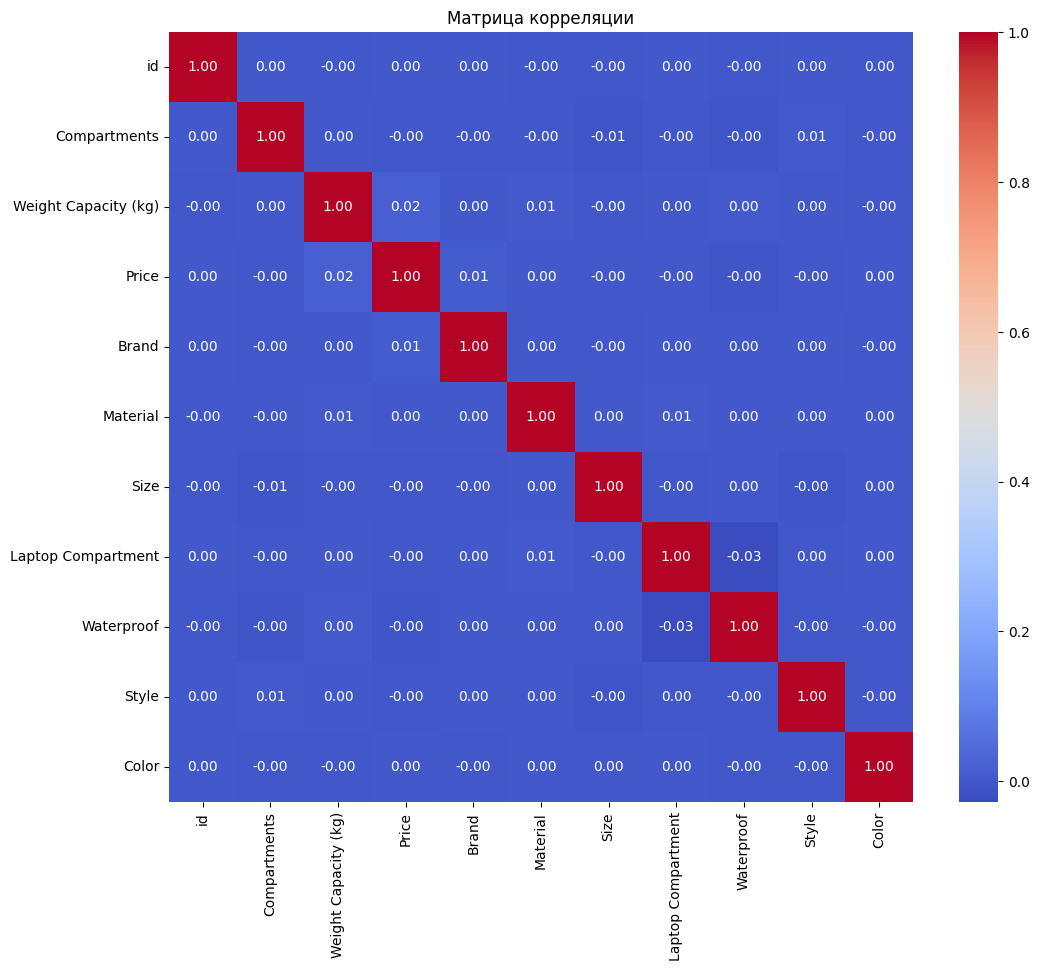

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,1,1,1,7.0,1,0,2,0,11.611723,112.15875
1,1,1,0,2,10.0,1,1,1,3,27.078537,68.88056
2,2,4,1,2,2.0,1,0,1,5,16.643760,39.17320
3,3,2,2,2,8.0,1,0,1,3,12.937220,80.60793
4,4,0,0,1,1.0,1,1,1,3,17.749338,86.02312


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

numeric_data = df[numeric_columns.tolist() + [col for col in categorical_cols]]
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Матрица корреляции")
plt.show()


df.head()

In [ ]:
print("Число пропущенных значений после обработки:")
print(df.isnull().sum())


Число пропущенных значений после обработки:
id                      0
Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import zscore

from catboost import CatBoostRegressor


categorical_features = ["Brand", "Material", "Size", "Laptop Compartment",
                        "Waterproof", "Style", "Color"]
numerical_features = ["Weight Capacity (kg)", "Compartments"]

for col in categorical_features:
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in numerical_features:
    df[col].fillna(df[col].median(), inplace=True)

def feature_engineering(df):

    df['Has_Laptop_Compartment'] = df['Laptop Compartment'].map({'Yes': 1, 'No': 0})
    df['Is_Waterproof'] = df['Waterproof'].map({'Yes': 1, 'No': 0})


    df['Size_Num'] = df['Size'].map({'Small': 1, 'Medium': 2, 'Large': 3})
    df['Material_Quality'] = df['Material'].map({
        'Leather': 3,
        'Canvas': 2,
        'Nylon': 2,
        'Polyester': 1
    })


    df['Quality_Capacity'] = df['Material_Quality'] * df['Weight Capacity (kg)']
    df['Size_Capacity'] = df['Size_Num'] * df['Weight Capacity (kg)']
    df['Capacity_Ratio'] = df['Weight Capacity (kg)'] / df['Compartments']
    df['Weight_Capacity_Ratio'] = df['Weight Capacity (kg)'] / df['Weight Capacity (kg)'].max()
    df['Weight_to_Compartments'] = df['Weight Capacity (kg)'] / (df['Compartments'] + 1)


    df['Brand_Material'] = df['Brand'].astype(str) + '_' + df['Material'].astype(str)
    df['Brand_Size'] = df['Brand'].astype(str) + '_' + df['Size'].astype(str)
    df['Style_Size'] = df['Style'] + '_' + df['Size']


    df['Compartments_Category'] = pd.cut(df['Compartments'],
        bins=[0, 2, 5, 10, np.inf], labels=['Few', 'Moderate', 'Many', 'Very Many'])

    return df

df = feature_engineering(df)

z_scores = np.abs(zscore(df[numerical_features]))
df = df[(z_scores < 3).all(axis=1)]

columns_to_encode = ['Brand', 'Material', 'Size', 'Laptop Compartment',
                     'Waterproof', 'Style', 'Color', 'Brand_Material',
                     'Brand_Size', 'Has_Laptop_Compartment', 'Is_Waterproof',
                     'Compartments_Category', 'Style_Size']

df_encoded = pd.get_dummies(df[columns_to_encode], columns=columns_to_encode, drop_first=True)

scaler = StandardScaler()
numerical_cols = ['Compartments', 'Weight Capacity (kg)',
                  'Weight_Capacity_Ratio', 'Weight_to_Compartments']
scaled_features = scaler.fit_transform(df[numerical_cols])

X = np.hstack([df_encoded, scaled_features])
y = df['Price']

final_categorical_features = ['Brand', 'Material', 'Size', 'Laptop Compartment',
                              'Waterproof', 'Style', 'Color', 'Brand_Material',
                              'Brand_Size', 'Compartments_Category', 'Style_Size']

final_numerical_features = ['Compartments', 'Weight Capacity (kg)',
                            'Capacity_Ratio', 'Size_Num',
                            'Material_Quality', 'Quality_Capacity',
                            'Size_Capacity', 'Weight_Capacity_Ratio',
                            'Weight_to_Compartments']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), final_numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), final_categorical_features)
    ])

X = preprocessor.fit_transform(df.drop('Price', axis=1))
y = df['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


catboost_params = {
    "iterations": 300,
    "learning_rate": 0.1,
    "depth": 6,
    "verbose": 0,
    "random_seed": 42
}

<ipython-input-67-70413b18f53a>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-67-70413b18f53a>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
model = CatBoostRegressor(**catboost_params)
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=0)


y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


RMSE: 38.9199
MAE: 33.6471
